In [1]:
# import dependencies
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import pprint

In [2]:
# open csv file
df = pd.read_csv("../data/cleaned/town_level_merged_for_eda.csv")

# open geojson file
gdf = gpd.read_file("../data/cleaned/census.geojson")

#### Clean data and functions for building index and model evaluation

In [3]:
# clean up missing values - fill funding and claims NaNs with 0,
# drop towns with zero population, and display remaining NaNs in ACS columns

# columns to check for NaNs
cols_to_check = [
    # "pct_river_corridor",
    # "pct_high_risk_NFHL",
    "median_income",
    "percent_elderly",
    "median_year_house_built",
    "pct_no_vehicle",
    "pct_renter_occupied",
    "pct_bachelors_or_higher",
    "pct_below_poverty",
    "percent_with_disability",
    "pct_mobile_home",
    # "funding_per_capita",
    # "log_funding_per_capita",
    # "funding_per_occupied_unit",
    # "log_funding_per_occupied_unit",
    # "claims_paid_per_capita",
    # "current_insurance_penetration",
]
# # print statement commented out, but left in case of testing (as with above columns)
# print("Missing values in key columns:")
# for col in cols_to_check:
#     missing = df[col].isna().sum()
#     print(f"{col}: {missing} missing values")

# fill funding and claims NaNs with 0
cols_to_fill = [
    "funding_per_capita",
    "log_funding_per_capita",
    "funding_per_occupied_unit",
    "log_funding_per_occupied_unit",
    "claims_paid_per_capita",
    "current_insurance_penetration",
]
df[cols_to_fill] = df[cols_to_fill].fillna(0)

# drop towns with zero population
print(f"\nTowns before filtering for zero population: {len(df)}")
df = df[df["total_population"] > 0]
print(f"Towns after filtering for zero population: {len(df)}\n")

# display remaining NaNs in ACS columns
print("Missing values in key columns:")
for col in cols_to_check:
    missing = df[col].isna().sum()
    print(f"{col}: {missing} missing values")


Towns before filtering for zero population: 256
Towns after filtering for zero population: 250

Missing values in key columns:
median_income: 3 missing values
percent_elderly: 0 missing values
median_year_house_built: 6 missing values
pct_no_vehicle: 0 missing values
pct_renter_occupied: 0 missing values
pct_bachelors_or_higher: 0 missing values
pct_below_poverty: 0 missing values
percent_with_disability: 0 missing values
pct_mobile_home: 0 missing values


In [4]:
def preprocess(df, cols_to_scale, log_transform=None):
    df = df.copy()

    # optional log transformation
    if log_transform:
        for col in log_transform:
            df[col] = np.log1p(df[col])

    # z-score variables
    scaler = StandardScaler()
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

    return df


def build_index(df, risk_vars, vuln_vars, funding_var, mode="add"):
    df = df.copy()

    # calculate risk and vulnerability indices as the mean of their respective (z-scored) variables
    if risk_vars:
        df["risk_index"] = df[risk_vars].mean(axis=1)
    else:
        df["risk_index"] = 0
    if vuln_vars:
        df["vuln_index"] = df[vuln_vars].mean(axis=1)
    else:
        df["vuln_index"] = 0

    # toggle between additive and weighted index construction
    if mode == "add":
        df["need_index"] = df["risk_index"] + df["vuln_index"]
    elif mode == "weighted":
        df["need_index"] = 0.5 * df["risk_index"] + 0.5 * df["vuln_index"]
    else:
        raise ValueError("mode must be 'add' or 'weighted'")

    # calculate the gap index as the difference between funding and need
    df["gap_index"] = df[funding_var] - df["need_index"]

    return df


def run_ols(df, X_vars, y_var):
    # add constant for intercept
    X = sm.add_constant(df[X_vars])
    y = df[y_var]

    # fit OLS model
    model = sm.OLS(y, X).fit()

    # save predictions and residuals back to dataframe
    df = df.copy()
    df["predicted"] = model.predict(X)
    df["residual"] = df[y_var] - df["predicted"]

    return df, model

In [5]:
def evaluate(df, model):
    # calculate correlation between gap index and residuals
    corr = df["gap_index"].corr(df["residual"])
    # calculate rank-based correlation between gap index and residuals
    # (i.e., do areas with higher gap index also tend to have higher residuals, even if not perfectly linear?)
    rank_corr_corr, _ = spearmanr(df["gap_index"], df["residual"])

    # compile evaluation summary
    summary = {
        "r2": model.rsquared,
        "adj_r2": model.rsquared_adj,
        "n_vars": len(model.params) - 1,
        "coef_signs": model.params.to_dict(),
        "gap_resid_corr": corr,
        "gap_resid_spearman_corr": rank_corr_corr,
    }

    return summary


def plot_basic(df, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # gap_index vs residual
    axes[0].scatter(df["gap_index"], df["residual"])
    axes[0].set_xlabel("Index Gap")
    axes[0].set_ylabel("OLS Residual")
    axes[0].set_title(title)
    axes[0].axhline(0, color="gray", linestyle="--")
    axes[0].axvline(0, color="gray", linestyle="--")

    # predicted vs residual
    axes[1].scatter(df["predicted"], df["residual"])
    axes[1].set_xlabel("Predicted Values")
    axes[1].set_ylabel("Residuals")
    axes[1].set_title("Predicted vs Residuals")
    axes[1].axhline(0, color="gray", linestyle="--")
    axes[1].axvline(0, color="gray", linestyle="--")

    plt.tight_layout()
    plt.show()


def plot_choropleths(
    df, gdf, value_cols=["gap_index", "residual"], geoid_col="GEOID", title_prefix=""
):

    # ensure types are correct for merging
    df[geoid_col] = df[geoid_col].astype(str)
    gdf[geoid_col] = gdf[geoid_col].astype(str)

    # Merge result df with geodataframe on GEOID
    plot_gdf = gdf.merge(df[[geoid_col] + value_cols], on=geoid_col, how="left")

    fig, axes = plt.subplots(1, len(value_cols), figsize=(7 * len(value_cols), 8))
    if len(value_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, value_cols):
        plot_gdf.plot(
            column=col,
            cmap="coolwarm",
            linewidth=0.2,
            edgecolor="gray",
            legend=True,
            ax=ax,
            missing_kwds={"color": "lightgrey", "label": "Missing"},
        )
        ax.set_title(f"{title_prefix}{col}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [6]:
def run_model_suite(df, gdf, model_specs):

    all_results = {}
    summary_rows = []

    for name, spec in model_specs.items():

        print(f"\n=== RUNNING: {name} ===")

        # extract spec components
        risk_vars = spec.get("risk", [])
        vuln_vars = spec.get("vuln", [])
        # spec components with defaults
        funding_var = spec.get("funding_var", "log_funding_per_capita")
        log_transform = spec.get("log_transform", None)
        index_mode = spec.get("index_mode", "add")
        do_plots = spec.get("do_plots", True)

        # define X variables and columns to scale based on spec
        X_vars = risk_vars + vuln_vars
        cols_to_scale = risk_vars + vuln_vars + [funding_var]

        # preprocess
        df_proc = preprocess(df, cols_to_scale, log_transform)

        # index
        df_idx = build_index(
            df_proc, risk_vars, vuln_vars, funding_var, mode=index_mode
        )

        # model
        df_model, model = run_ols(df_idx, X_vars, funding_var)

        # evaluate
        metrics = evaluate(df_model, model)
        metrics["model"] = name

        summary_rows.append(metrics)

        # store full outputs
        all_results[name] = {"df": df_model, "model": model, "metrics": metrics}

        # plots
        if do_plots:
            plot_basic(df_model, title=name)
            plot_choropleths(df_model, gdf, title_prefix=name + " - ")

        # print(metrics)

    summary_df = pd.DataFrame(summary_rows).sort_values(by="r2", ascending=False)

    print("\n=== SUMMARY ===")
    display(summary_df)

    return all_results, summary_df

In [7]:
def get_extremes(df, col, n=10):
    return {
        "lowest": df.nsmallest(n, col)[["town_name", col]],
        "highest": df.nlargest(n, col)[["town_name", col]],
    }

# Define inputs and evalute index / models

In [8]:
model_specs = {
    "baseline_exposure": {"risk": ["pct_river_corridor"]},
    "baseline_vulnerability": {
        "vuln": ["pct_below_poverty", "percent_elderly", "pct_no_vehicle"],
        "log_transform": ["pct_below_poverty"],
    },
    "core_model": {
        "risk": ["pct_river_corridor"],
        "vuln": ["pct_below_poverty", "percent_elderly", "pct_no_vehicle"],
        "log_transform": ["pct_below_poverty"],
    },
    "expanded_model": {
        "risk": ["pct_river_corridor"],
        "vuln": [
            "pct_below_poverty",
            "percent_elderly",
            "pct_no_vehicle",
            "pct_renter_occupied",
            "pct_mobile_home",
        ],
        "log_transform": ["pct_below_poverty"],
    },
    "claims_only": {"risk": ["claims_paid_per_capita"]},
    "combined": {
        "risk": ["pct_river_corridor"],
        "vuln": ["pct_below_poverty", "percent_elderly"],
        "log_transform": ["pct_below_poverty"],
    },
}


=== RUNNING: baseline_exposure_add ===


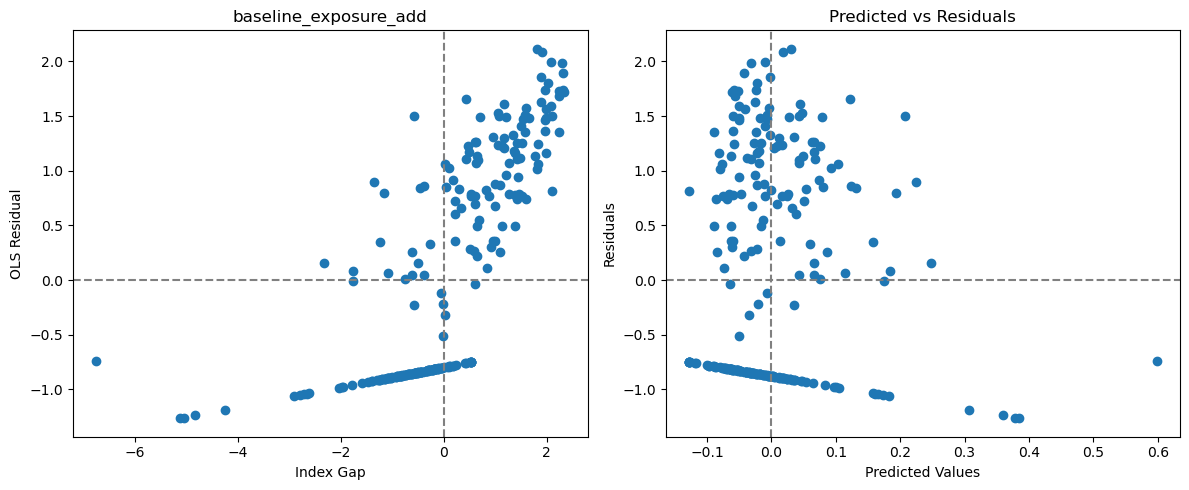

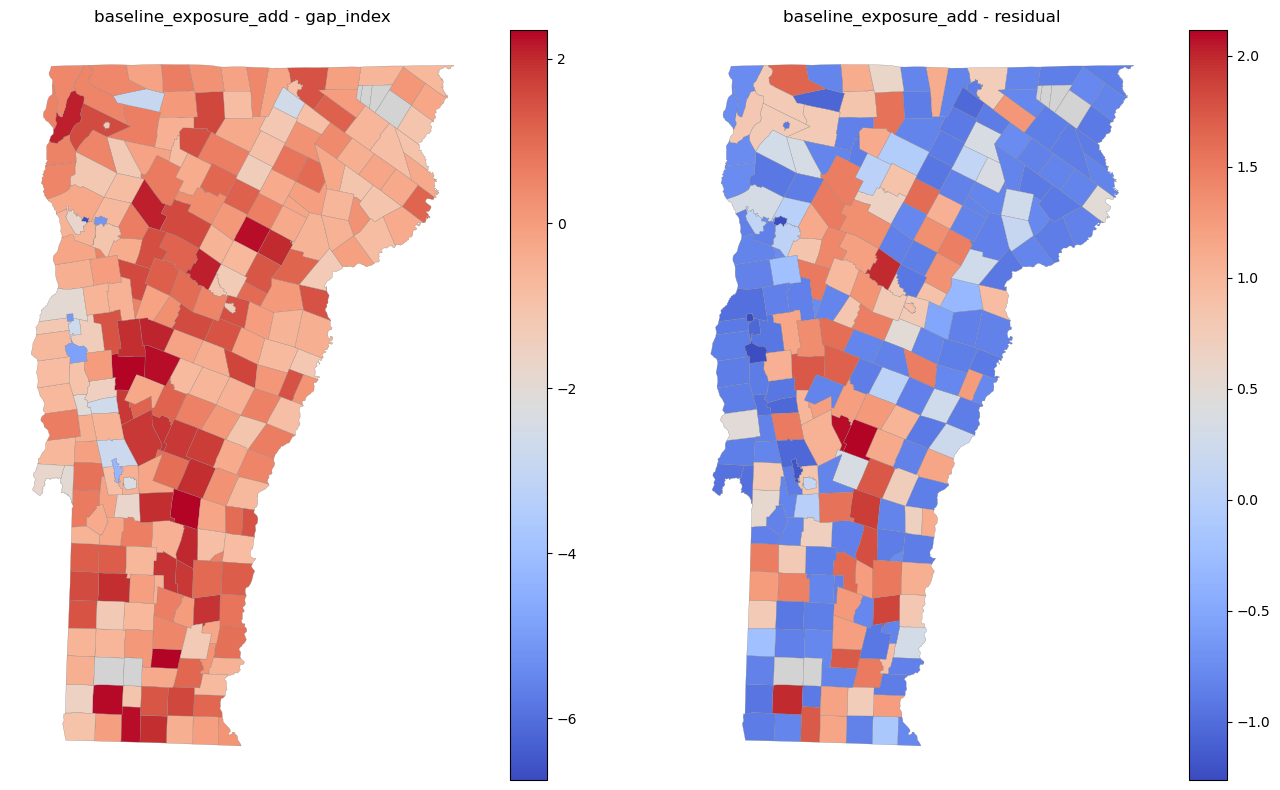


=== RUNNING: baseline_vulnerability_add ===


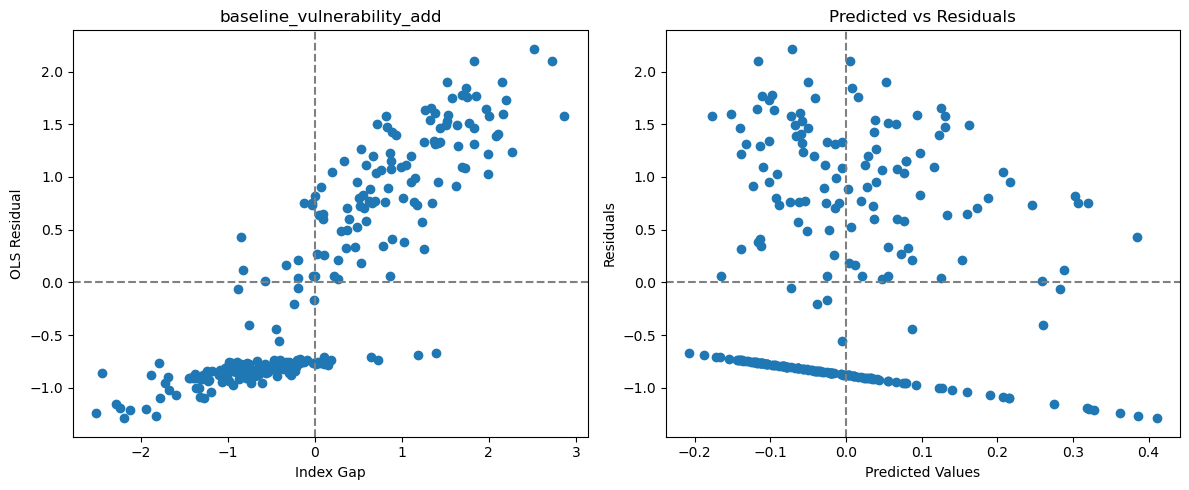

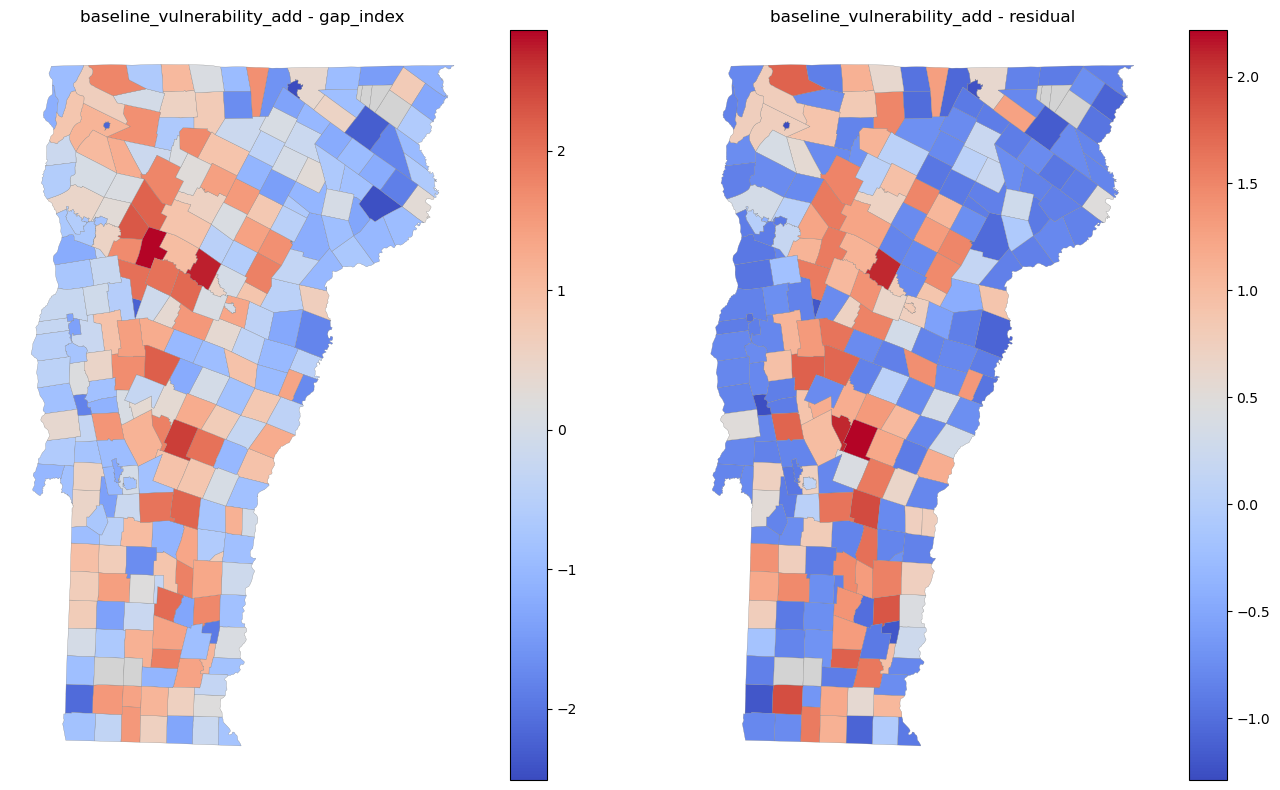


=== RUNNING: core_model_add ===


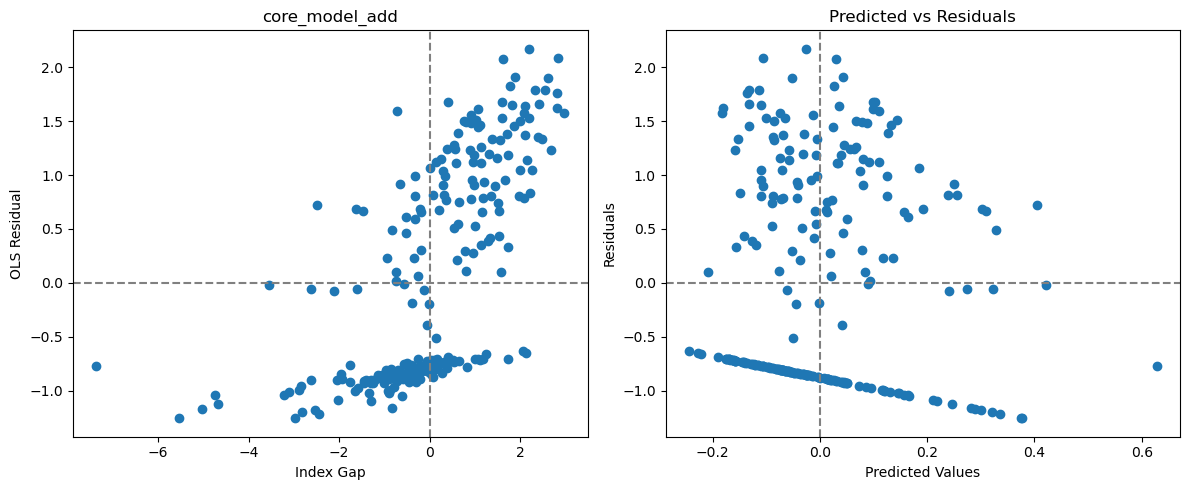

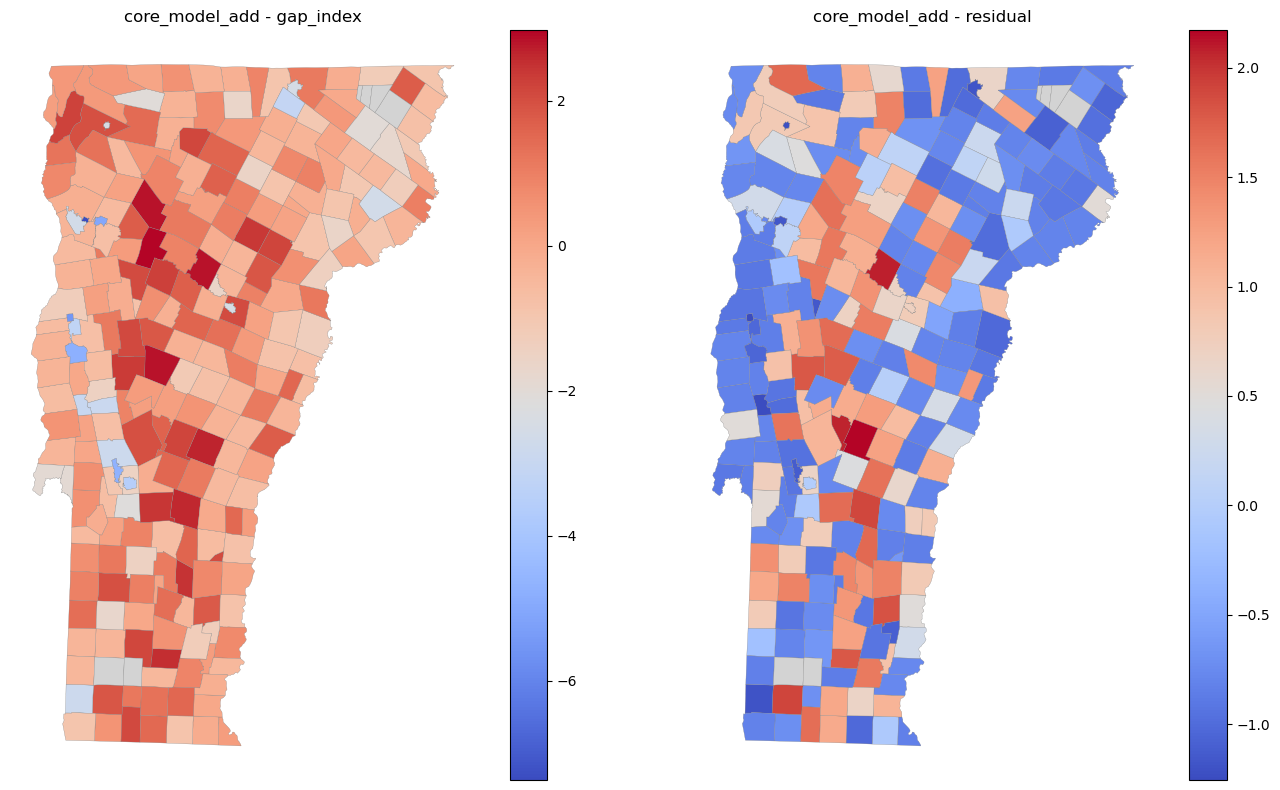


=== RUNNING: expanded_model_add ===


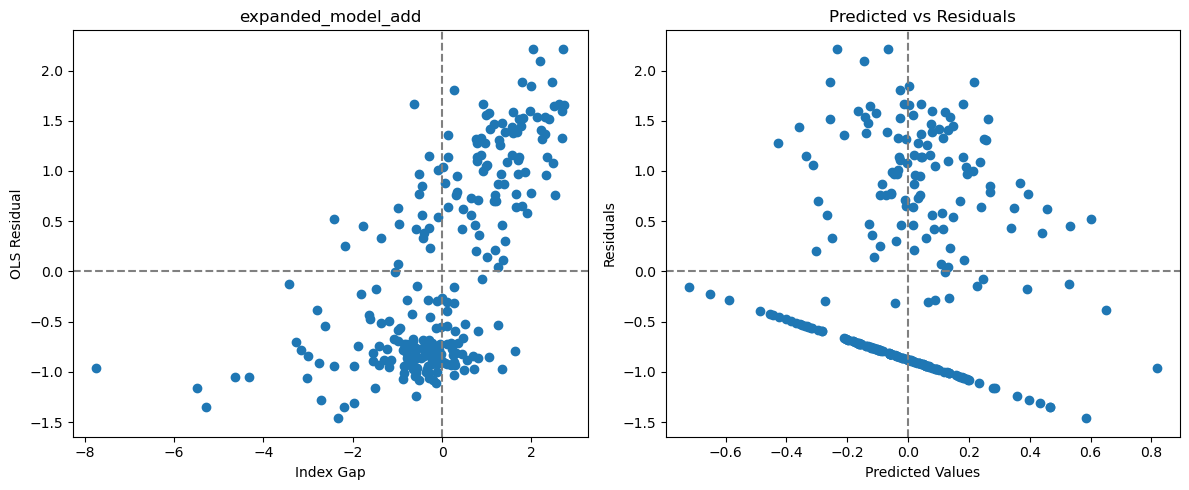

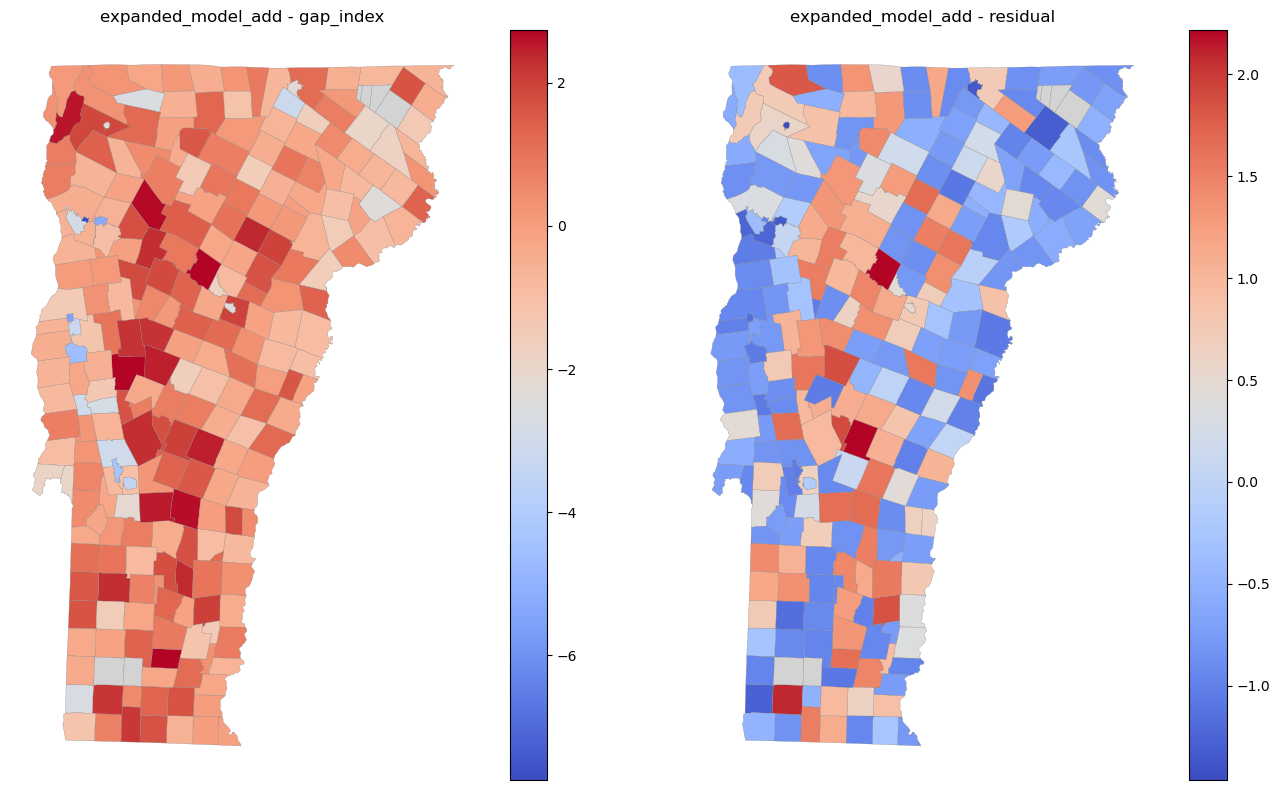


=== RUNNING: claims_only_add ===


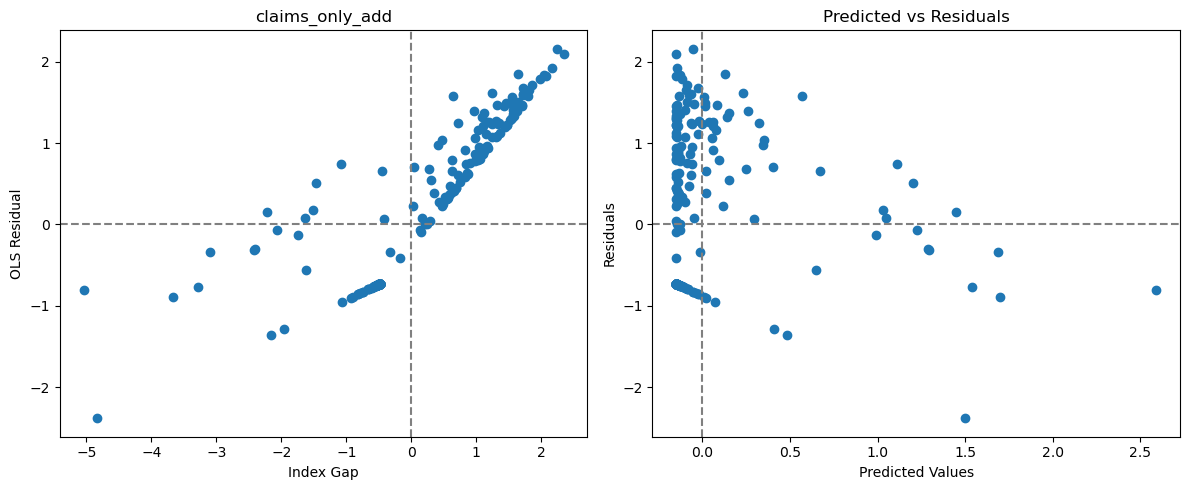

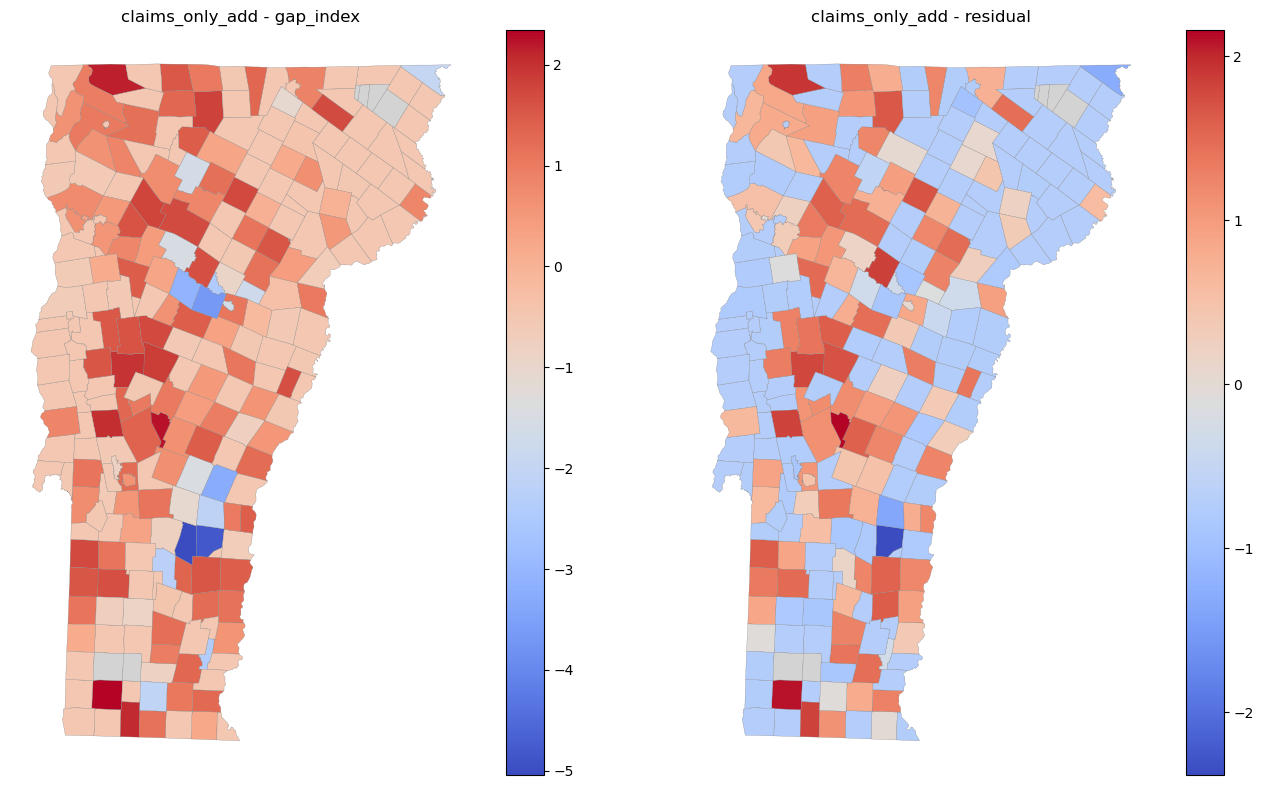


=== RUNNING: combined_add ===


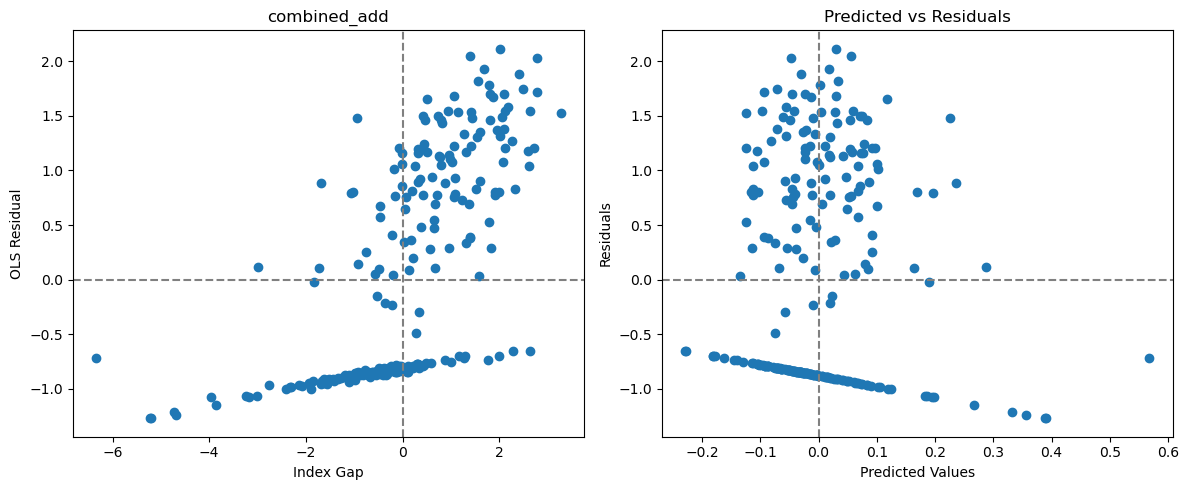

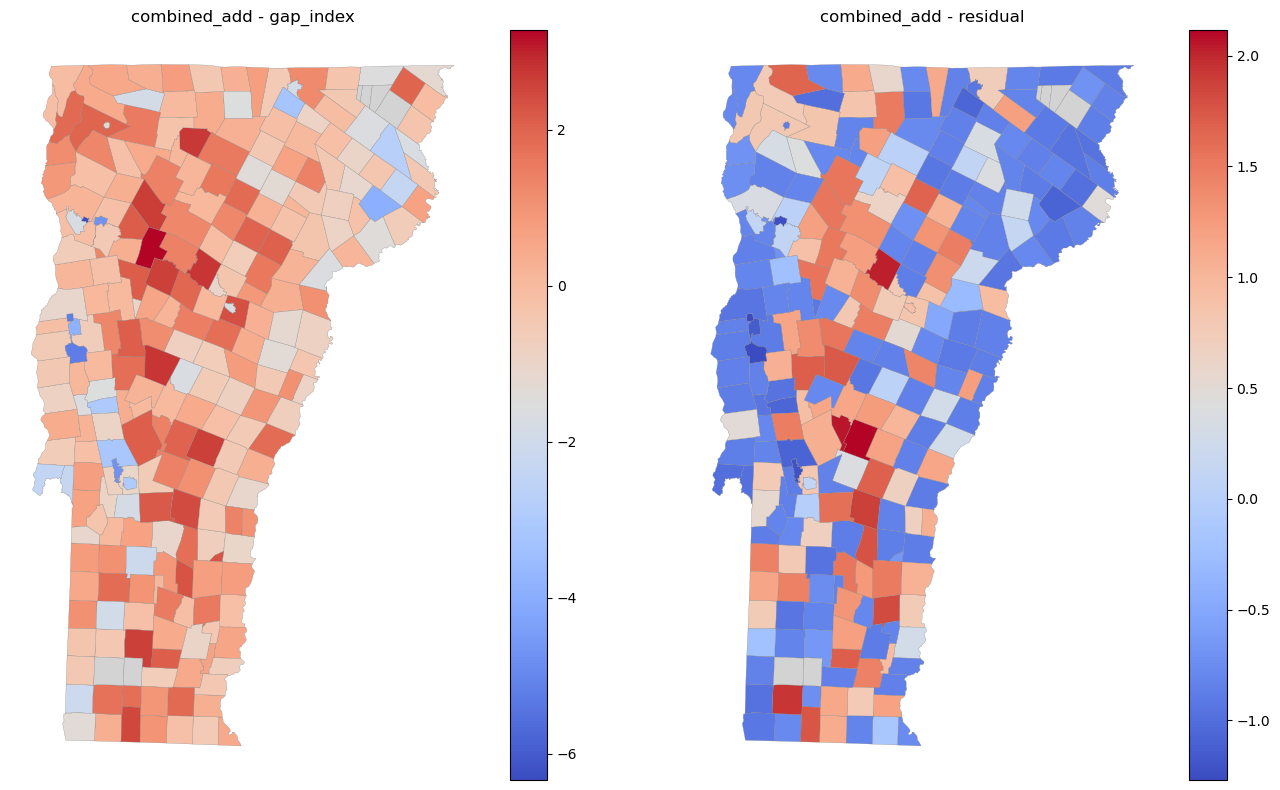


=== RUNNING: baseline_exposure_weighted ===


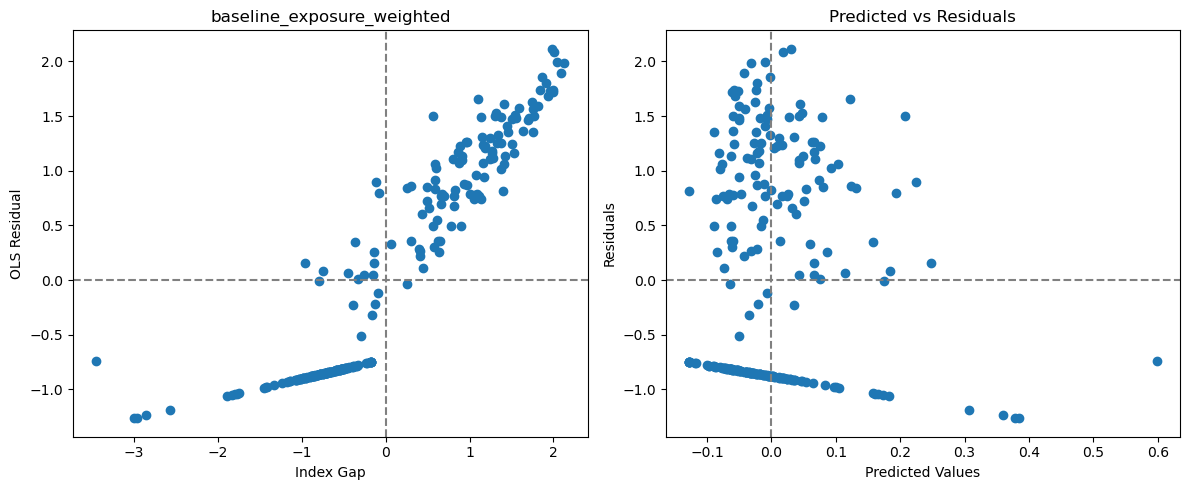

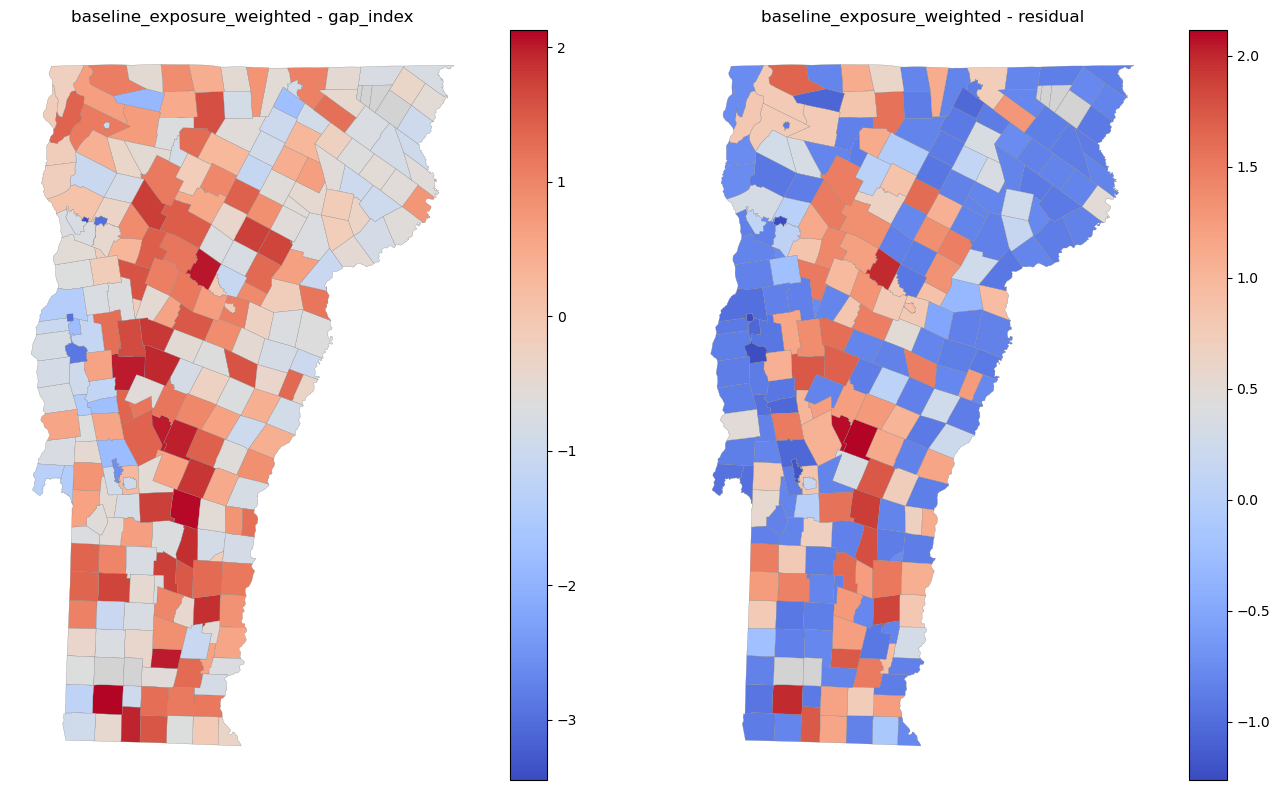


=== RUNNING: baseline_vulnerability_weighted ===


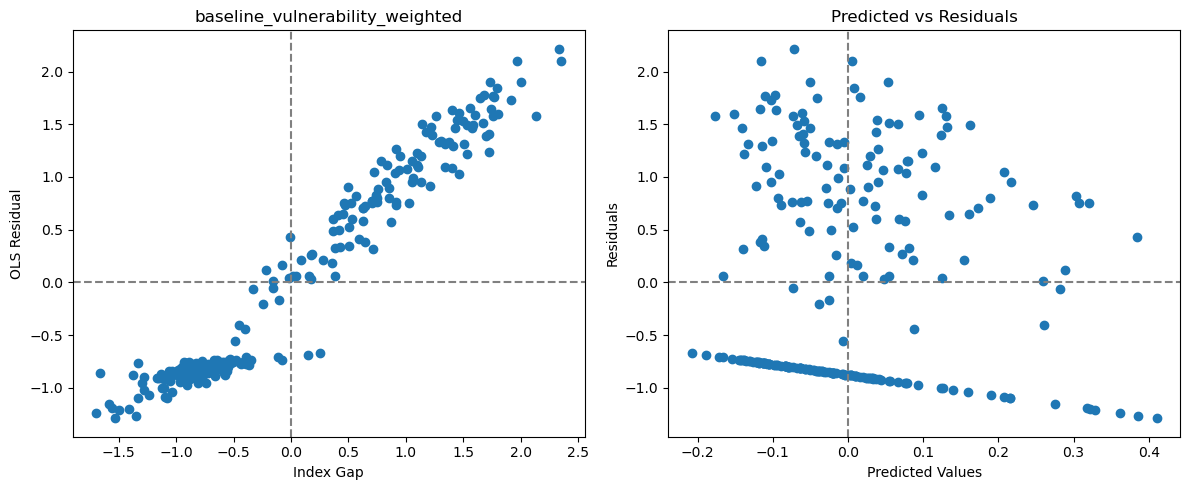

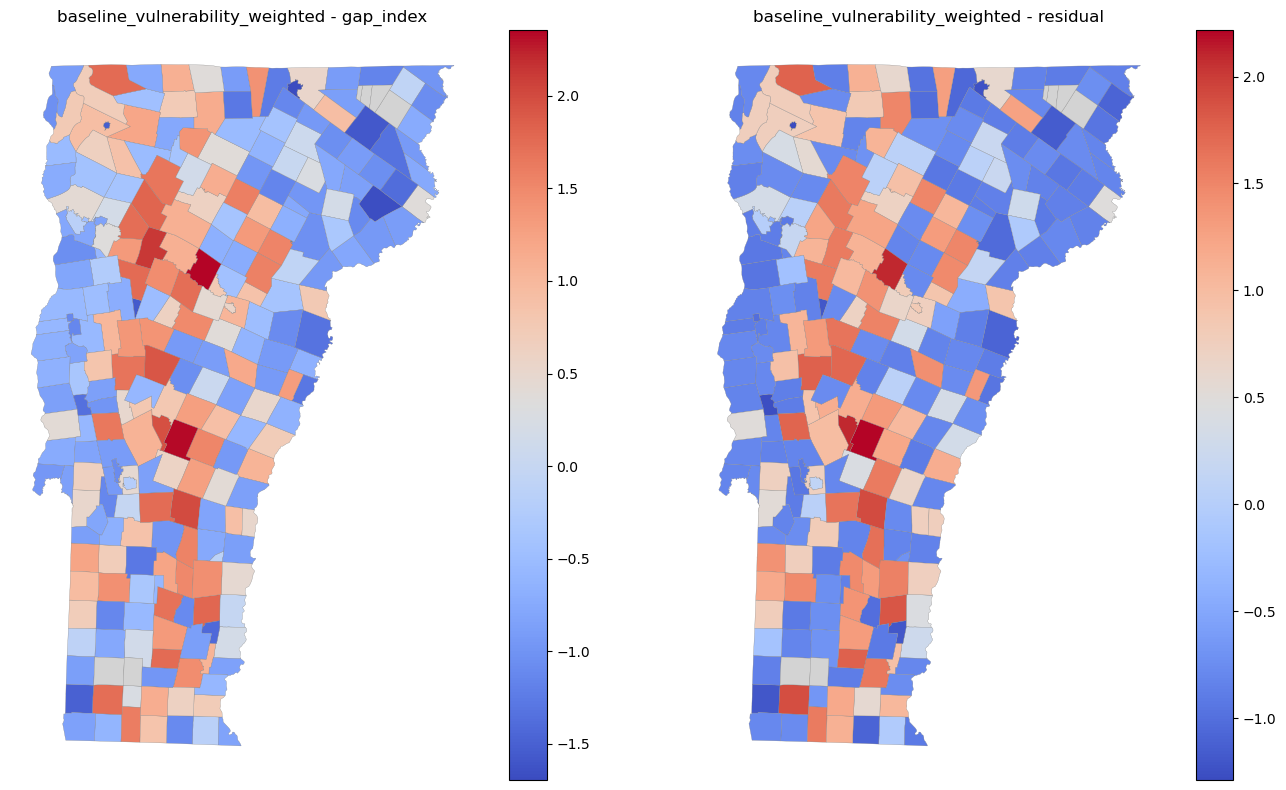


=== RUNNING: core_model_weighted ===


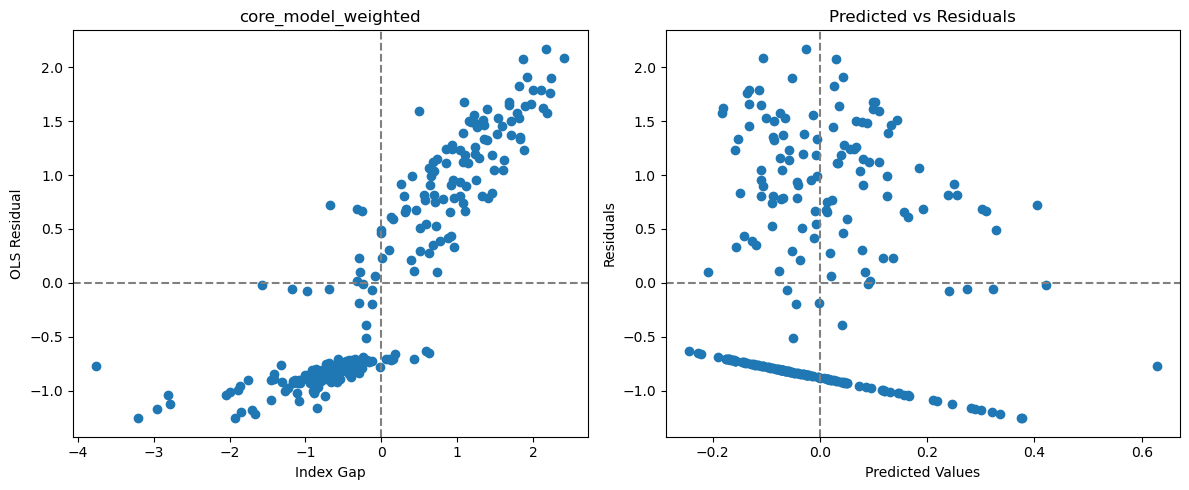

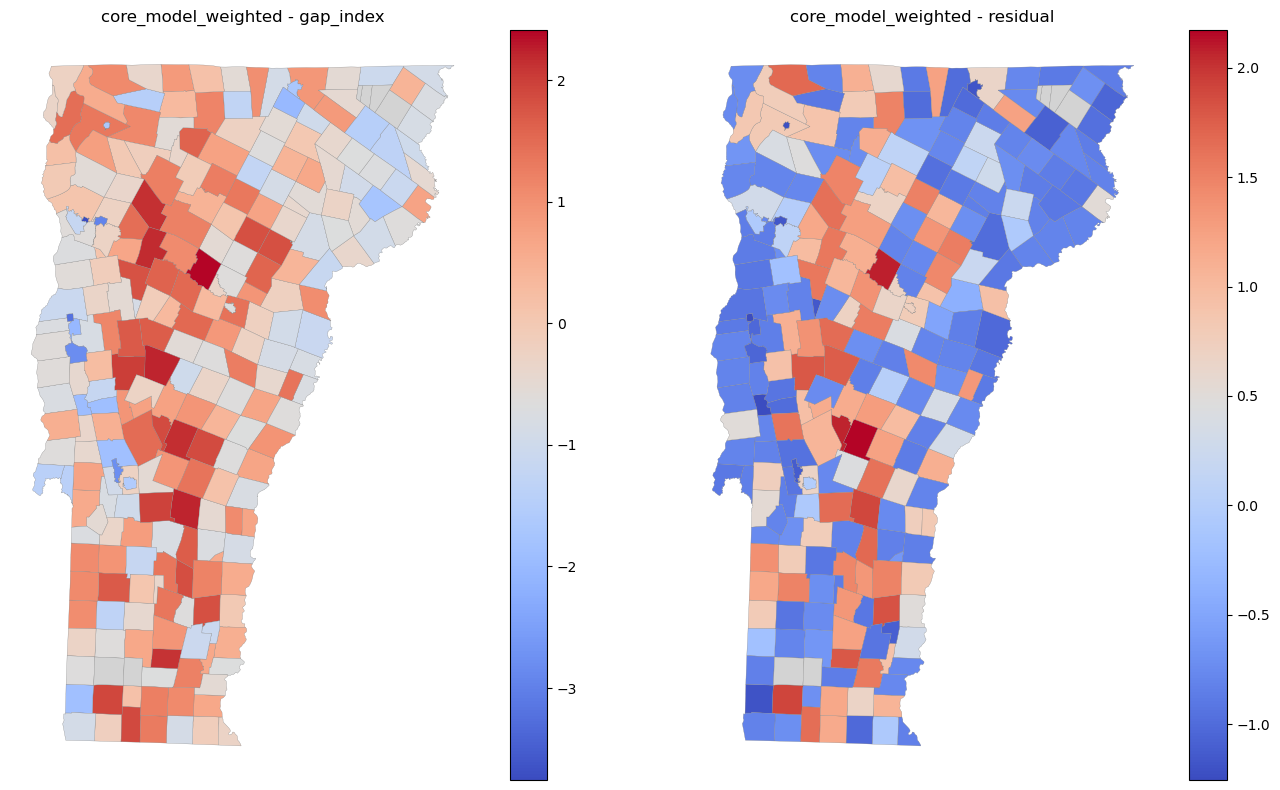


=== RUNNING: expanded_model_weighted ===


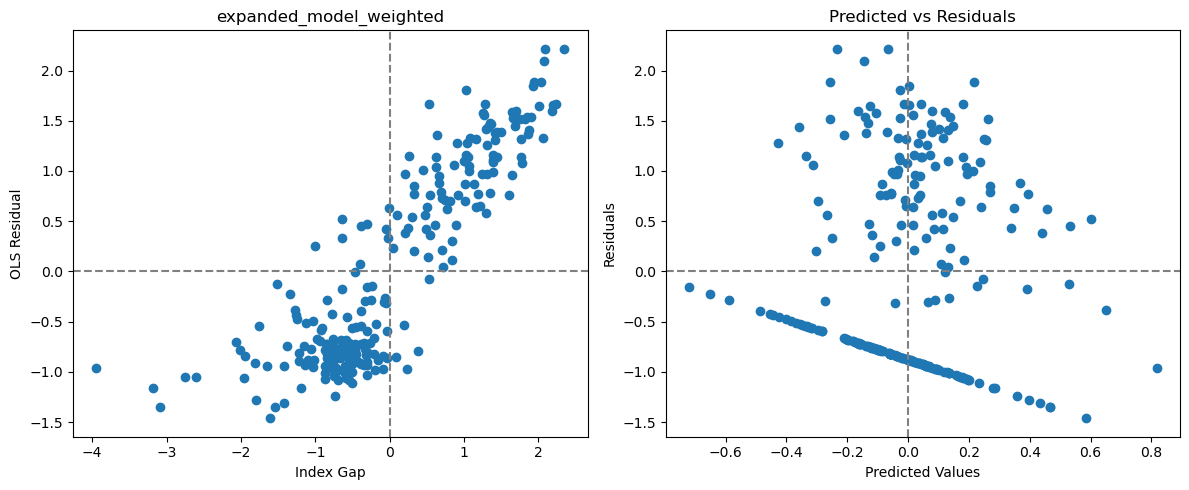

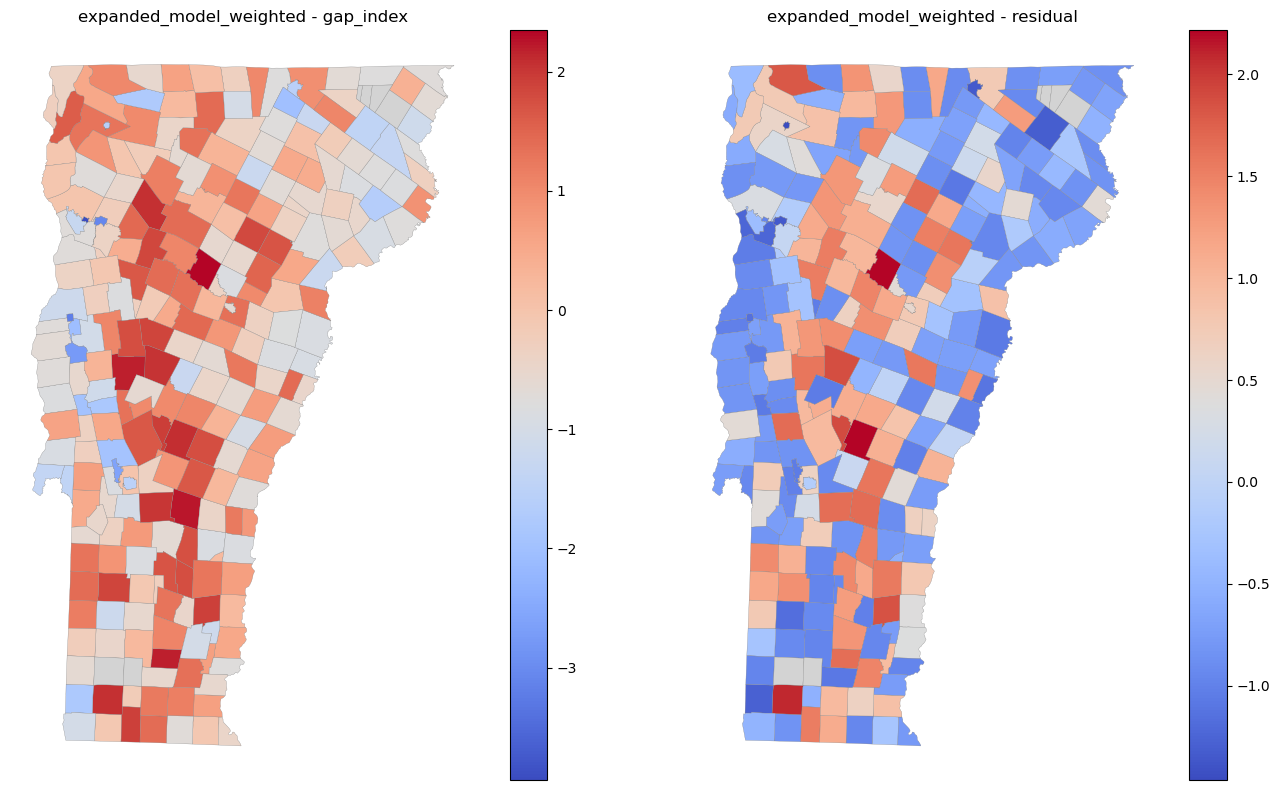


=== RUNNING: claims_only_weighted ===


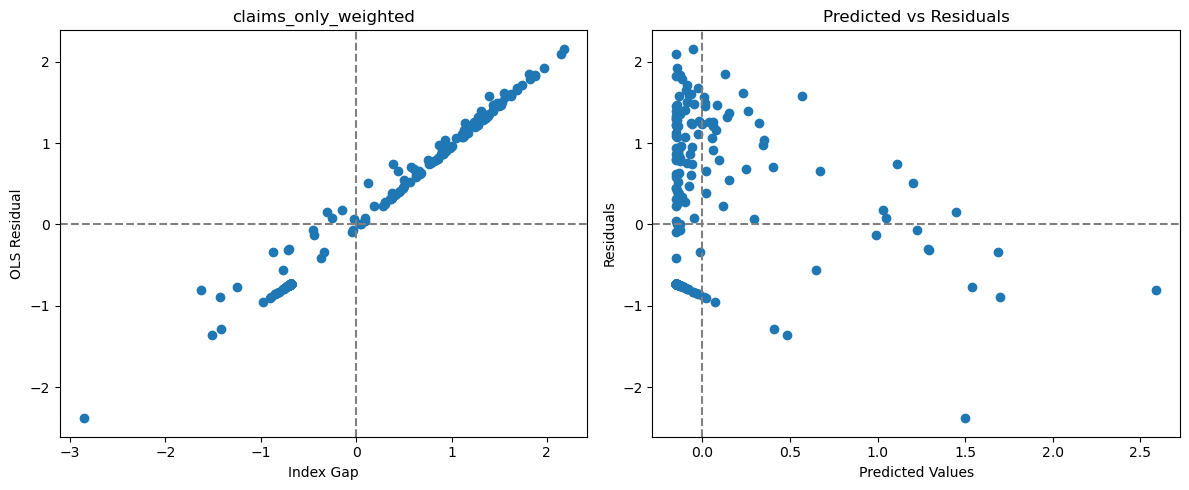

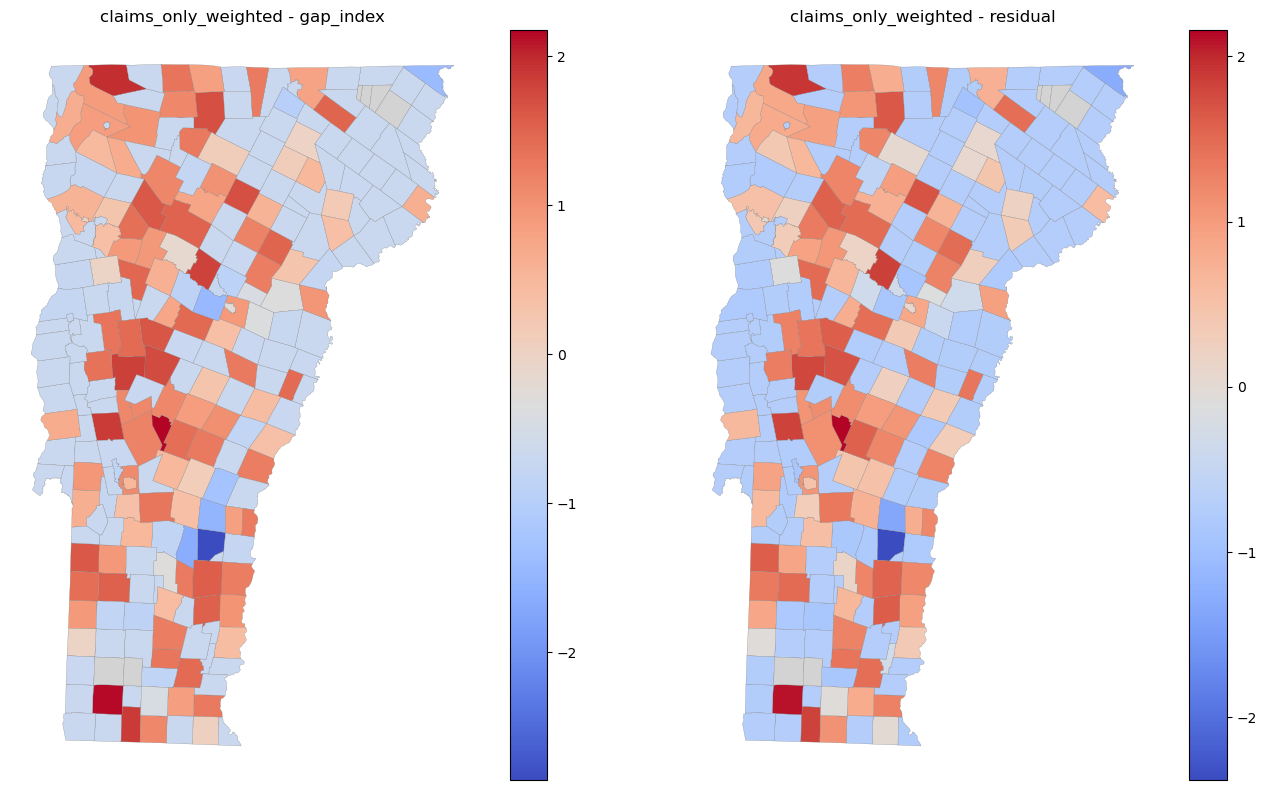


=== RUNNING: combined_weighted ===


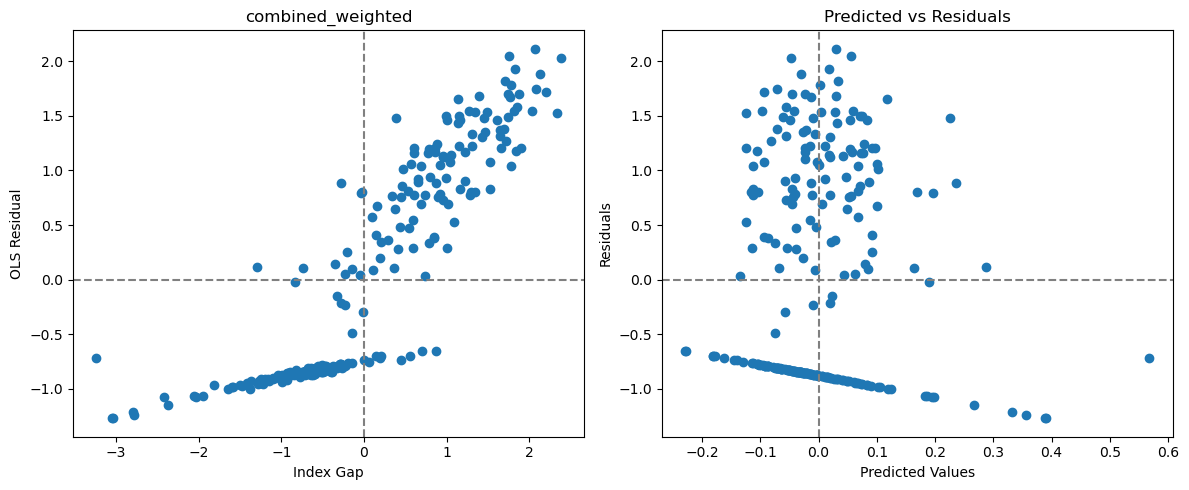

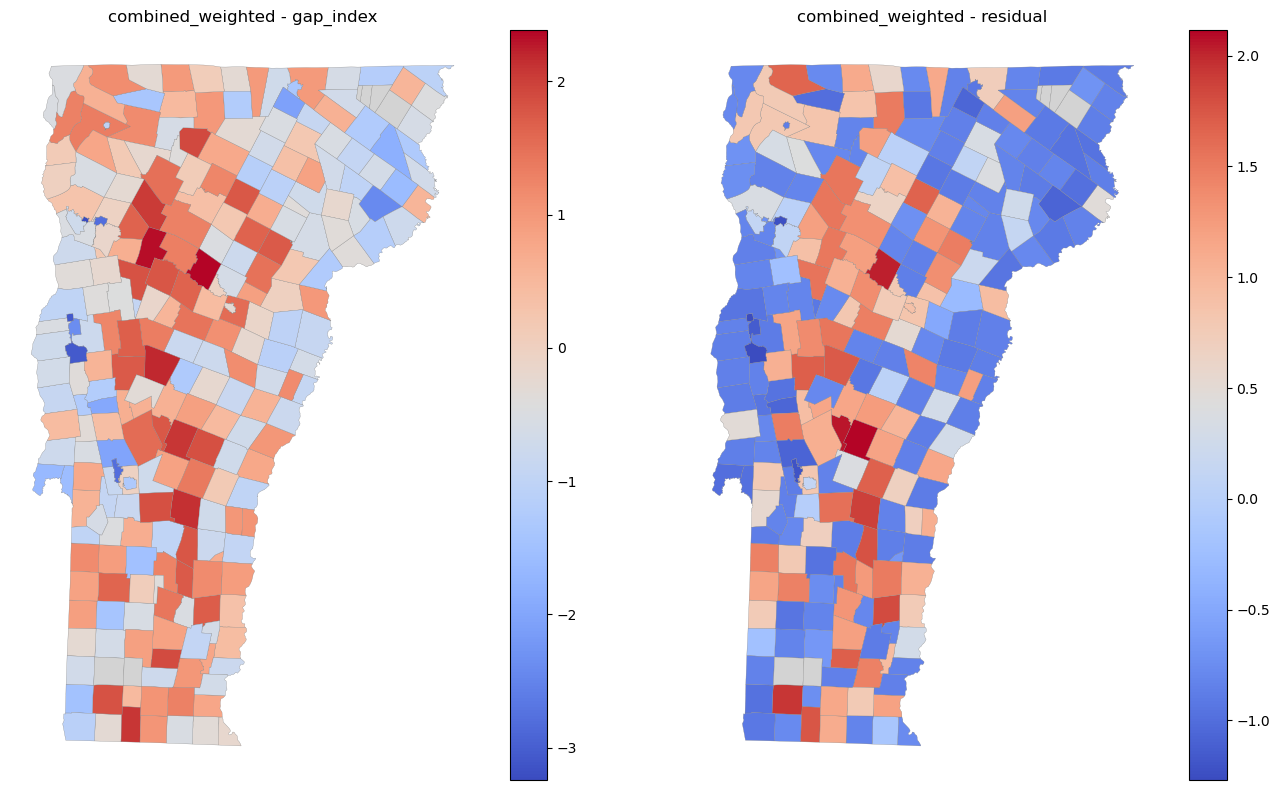


=== SUMMARY ===


,r2,adj_r2,n_vars,coef_signs,gap_resid_corr,gap_resid_spearman_corr,model
4,0.144063,0.140611,1,"{'const': 1.0679391398982219e-16, 'claims_paid...",0.830529,0.902849,claims_only_add
10,0.144063,0.140611,1,"{'const': 1.0679391398982219e-16, 'claims_paid...",0.991632,0.977210,claims_only_weighted
3,0.047952,0.024445,6,"{'const': 2.710505431213761e-18, 'pct_river_co...",0.645361,0.654326,expanded_model_add
9,0.047952,0.024445,6,"{'const': 2.710505431213761e-18, 'pct_river_co...",0.869007,0.816628,expanded_model_weighted
2,0.018217,0.002188,4,"{'const': 2.710505431213761e-18, 'pct_river_co...",0.653617,0.786322,core_model_add
8,0.018217,0.002188,4,"{'const': 2.710505431213761e-18, 'pct_river_co...",0.886313,0.928370,core_model_weighted
1,0.014376,0.002356,3,"{'const': 2.710505431213761e-18, 'pct_below_po...",0.882920,0.914141,baseline_vulnerability_add
7,0.014376,0.002356,3,"{'const': 2.710505431213761e-18, 'pct_below_po...",0.975084,0.956283,baseline_vulnerability_weighted
5,0.010158,-0.001913,3,"{'const': 2.710505431213761e-18, 'pct_river_co...",0.661482,0.822558,combined_add
11,0.010158,-0.001913,3,"{'const': 2.710505431213761e-18, 'pct_river_co...",0.888095,0.949317,combined_weighted


In [9]:
# results, summary = run_model_suite(df, gdf, model_specs)

expanded_specs = {}
for mode in ["add", "weighted"]:
    for name, spec in model_specs.items():
        new_name = f"{name}_{mode}"
        expanded_specs[new_name] = {**spec, "index_mode": mode}

results, summary = run_model_suite(df, gdf, expanded_specs)

In [10]:
# display head and tails of gap index for core model
# get_extremes(results["core_model"]["df"], "gap_index")

get_extremes(results["core_model_add"]["df"], "gap_index")

{'lowest':                town_name  gap_index
 250        Winooski city  -7.365740
 213       Vergennes city  -5.541007
 68   Essex Junction city  -5.037176
 240       Weybridge town  -4.741303
 161         Proctor town  -4.681324
 174         Rutland city  -3.559190
 220         Waltham town  -3.209244
 54         Coventry town  -3.120035
 242         Whiting town  -2.978452
 112       Leicester town  -2.891045,
 'highest':            town_name  gap_index
 22       Bolton town   2.971619
 127   Middlesex town   2.833718
 86    Granville town   2.820675
 212   Underhill town   2.813659
 10      Barnard town   2.678982
 157    Plymouth town   2.618306
 221   Wardsboro town   2.540429
 3       Andover town   2.480400
 186  Shrewsbury town   2.424065
 252    Woodbury town   2.393294}

In [11]:
for i, row in summary.iterrows():
    print(f"Model: {row['model']}")
    pprint.pprint(row["coef_signs"])
    print()

Model: claims_only_add
{'claims_paid_per_capita': 0.379555673916369, 'const': 1.0679391398982219e-16}

Model: claims_only_weighted
{'claims_paid_per_capita': 0.379555673916369, 'const': 1.0679391398982219e-16}

Model: expanded_model_add
{'const': 2.710505431213761e-18,
 'pct_below_poverty': 0.017241518744231972,
 'pct_mobile_home': -0.15088103370979966,
 'pct_no_vehicle': 0.030627728398810318,
 'pct_renter_occupied': 0.1002191247964207,
 'pct_river_corridor': 0.023088829173087227,
 'percent_elderly': 0.028043045754984362}

Model: expanded_model_weighted
{'const': 2.710505431213761e-18,
 'pct_below_poverty': 0.017241518744231972,
 'pct_mobile_home': -0.15088103370979966,
 'pct_no_vehicle': 0.030627728398810318,
 'pct_renter_occupied': 0.1002191247964207,
 'pct_river_corridor': 0.023088829173087227,
 'percent_elderly': 0.028043045754984362}

Model: core_model_add
{'const': 2.710505431213761e-18,
 'pct_below_poverty': -0.001674243844394375,
 'pct_no_vehicle': 0.09788028080972082,
 'pct_ri